# TP : Apprentissage Supervisé - Classification (exercice)
## Dataset : Spambase (détection de spam, OpenML)

**Algorithmes couverts :**

| Algo | Famille | Caractéristique |
|---|---|---|
| Régression Logistique | Linéaire | Rapide, interprétable |
| KNN | Instance-based | Simple, sensible à l'échelle |
| Decision Tree | Arbre | Interprétable, sujet à l'overfitting |
| Random Forest | Ensemble (bagging) | Robuste, peu de réglage |
| XGBoost | Ensemble (boosting) | Souvent le plus performant |

**Datamap (dictionnaire des données) :** 57 mesures extraites du texte de chaque email, regroupées en 3 familles.

| Famille de colonnes | Nombre | Description |
|---|---|---|
| `word_freq_*` | 48 | % d'occurrences d'un mot donné dans l'email (ex : `word_freq_free`, `word_freq_money`) |
| `char_freq_*` | 6 | % d'occurrences d'un caractère donné (`;`, `(`, `[`, `!`, `$`, `#`) |
| `capital_run_length_*` | 3 | Longueur des séquences de lettres majuscules (moyenne, la plus longue, totale) |

**Cible :** `class` : 0 = non-spam, 1 = spam.

> **Version exercice** : les cellules marquées `# TODO` sont à compléter. Le reste (imports, chargement des données, affichages) est déjà fourni.
> Installe les dépendances une seule fois avec `pip install -r requirements.txt` depuis `cours_ml/todo/` (voir le README de ce dossier). Ce TP s'inspire de `cours_ml/02_supervise/tp_classification.ipynb` (même méthode, données différentes et plus volumineuses : 4601 emails contre 569 tumeurs).

---
## 0. Imports & configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)

sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42


---
## 1. Chargement & exploration

In [2]:
# Spambase : 4601 emails, 57 mesures (frequences de mots/caracteres, longueurs de sequences en majuscules)
# Chargement depuis OpenML (dataset public, aucune authentification requise)
spam = fetch_openml(name='spambase', version='active', as_frame=True, parser='auto')
df_raw = spam.frame.drop(columns=['class']).astype(float)
y = spam.frame['class'].astype(int).values
X = df_raw.values
feature_names = list(df_raw.columns)
class_names = ['non-spam', 'spam']

print(f"Dimensions : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes")
df_raw.head()


Dimensions : 4601 lignes x 57 colonnes


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,word_freq_will,word_freq_people,word_freq_report,word_freq_addresses,word_freq_free,word_freq_business,word_freq_email,word_freq_you,word_freq_credit,word_freq_your,word_freq_font,word_freq_000,word_freq_money,word_freq_hp,word_freq_hpl,word_freq_george,word_freq_650,word_freq_lab,word_freq_labs,word_freq_telnet,word_freq_857,word_freq_data,word_freq_415,word_freq_85,word_freq_technology,word_freq_1999,word_freq_parts,word_freq_pm,word_freq_direct,word_freq_cs,word_freq_meeting,word_freq_original,word_freq_project,word_freq_re,word_freq_edu,word_freq_table,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,0.00,0.64,0.00,0.00,0.00,0.32,0.00,1.29,1.93,0.00,0.96,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61.0,278.0
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,0.21,0.79,0.65,0.21,0.14,0.14,0.07,0.28,3.47,0.00,1.59,0.0,0.43,0.43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.07,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101.0,1028.0
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,0.38,0.45,0.12,0.00,1.75,0.06,0.06,1.03,1.36,0.32,0.51,0.0,1.16,0.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.06,0.0,0.0,0.12,0.0,0.06,0.06,0.0,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485.0,2259.0
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40.0,191.0
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40.0,191.0


In [3]:
df_raw.describe().round(2)

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,word_freq_will,word_freq_people,word_freq_report,word_freq_addresses,word_freq_free,word_freq_business,word_freq_email,word_freq_you,word_freq_credit,word_freq_your,word_freq_font,word_freq_000,word_freq_money,word_freq_hp,word_freq_hpl,word_freq_george,word_freq_650,word_freq_lab,word_freq_labs,word_freq_telnet,word_freq_857,word_freq_data,word_freq_415,word_freq_85,word_freq_technology,word_freq_1999,word_freq_parts,word_freq_pm,word_freq_direct,word_freq_cs,word_freq_meeting,word_freq_original,word_freq_project,word_freq_re,word_freq_edu,word_freq_table,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total
count,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00
mean,0.10,0.21,0.28,0.07,0.31,0.10,0.11,0.11,0.09,0.24,0.06,0.54,0.09,0.06,0.05,0.25,0.14,0.18,1.66,0.09,0.81,0.12,0.10,0.09,0.55,0.27,0.77,0.12,0.10,0.10,0.06,0.05,0.10,0.05,0.11,0.10,0.14,0.01,0.08,0.06,0.04,0.13,0.05,0.08,0.30,0.18,0.01,0.03,0.04,0.14,0.02,0.27,0.08,0.04,5.19,52.17,283.29
std,0.31,1.29,0.50,1.40,0.67,0.27,0.39,0.40,0.28,0.64,0.20,0.86,0.30,0.34,0.26,0.83,0.44,0.53,1.78,0.51,1.20,1.03,0.35,0.44,1.67,0.89,3.37,0.54,0.59,0.46,0.40,0.33,0.56,0.33,0.53,0.40,0.42,0.22,0.43,0.35,0.36,0.77,0.22,0.62,1.01,0.91,0.08,0.29,0.24,0.27,0.11,0.82,0.25,0.43,31.73,194.89,606.35
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.59,6.00,35.00
50%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.10,0.00,0.00,0.00,0.00,0.00,0.00,1.31,0.00,0.22,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.06,0.00,0.00,0.00,0.00,2.28,15.00,95.00
75%,0.00,0.00,0.42,0.00,0.38,0.00,0.00,0.00,0.00,0.16,0.00,0.80,0.00,0.00,0.00,0.10,0.00,0.00,2.64,0.00,1.27,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.11,0.00,0.00,0.00,0.00,0.19,0.00,0.32,0.05,0.00,3.71,43.00,266.00
max,4.54,14.28,5.10,42.81,10.00,5.88,7.27,11.11,5.26,18.18,2.61,9.67,5.55,10.00,4.41,20.00,7.14,9.09,18.75,18.18,11.11,17.10,5.45,12.50,20.83,16.66,33.33,9.09,14.28,5.88,12.50,4.76,18.18,4.76,20.00,7.69,6.89,8.33,11.11,4.76,7.14,14.28,3.57,20.00,21.42,22.05,2.17,10.00,4.38,9.75,4.08,32.48,6.00,19.83,1102.50,9989.00,15841.00


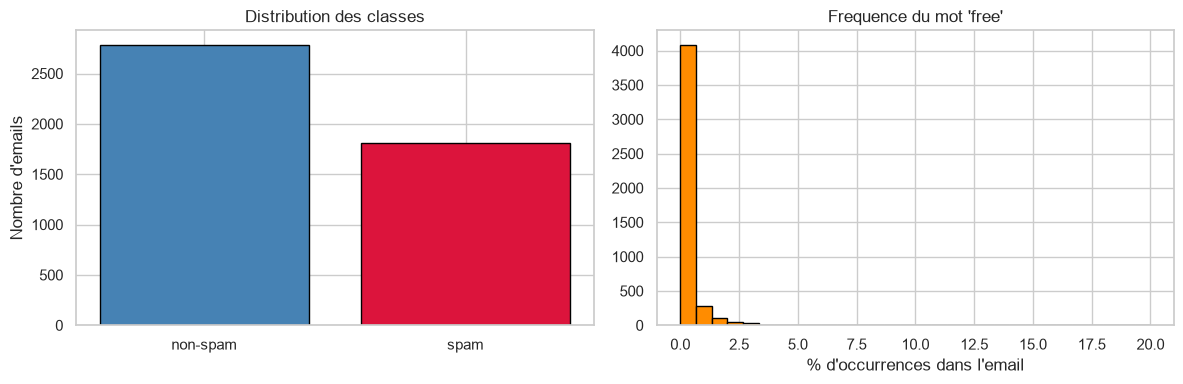

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(class_names, np.bincount(y), color=['steelblue', 'crimson'], edgecolor='k')
axes[0].set_title('Distribution des classes')
axes[0].set_ylabel('Nombre d\'emails')

axes[1].hist(df_raw['word_freq_free'], bins=30, color='darkorange', edgecolor='k')
axes[1].set_title("Frequence du mot 'free'")
axes[1].set_xlabel('% d\'occurrences dans l\'email')

plt.tight_layout()
plt.show()


---
## 2. Prétraitement & split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train : {X_train.shape[0]} échantillons | Test : {X_test.shape[0]} échantillons")
print(f"Train classes : {dict(zip(class_names, np.bincount(y_train)))}")
print(f"Test  classes : {dict(zip(class_names, np.bincount(y_test)))}")

# Normalisation (intégrée dans les pipelines ci-dessous)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


Train : 3680 échantillons | Test : 921 échantillons
Train classes : {'non-spam': np.int64(2230), 'spam': np.int64(1450)}
Test  classes : {'non-spam': np.int64(558), 'spam': np.int64(363)}


---
## 3. Régression Logistique

Modèle linéaire qui prédit la **probabilité** d'appartenir à une classe via la fonction sigmoïde.

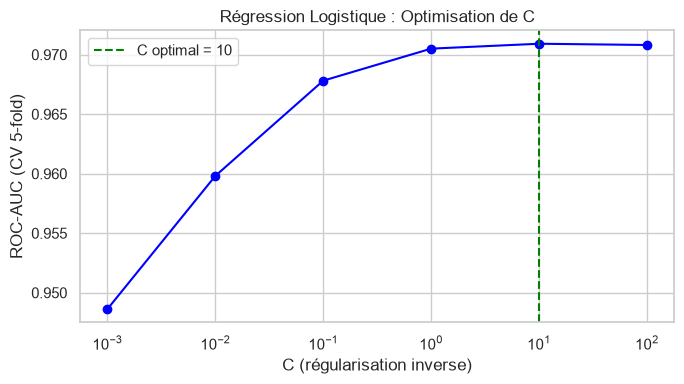

C optimal : 10 | ROC-AUC CV : 0.9709


In [6]:
# Optimisation : recherche du meilleur C par cross-validation
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
cv_scores_lr = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for C in C_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_STATE)),
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_scores_lr.append(scores.mean())

best_C = C_values[np.argmax(cv_scores_lr)]

plt.figure(figsize=(7, 4))
plt.semilogx(C_values, cv_scores_lr, 'bo-')
plt.axvline(best_C, color='green', linestyle='--', label=f'C optimal = {best_C}')
plt.xlabel('C (régularisation inverse)')
plt.ylabel('ROC-AUC (CV 5-fold)')
plt.title('Régression Logistique : Optimisation de C')
plt.legend()
plt.tight_layout()
plt.show()

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=best_C, max_iter=1000, random_state=RANDOM_STATE)),
])
pipe_lr.fit(X_train, y_train)
print(f"C optimal : {best_C} | ROC-AUC CV : {max(cv_scores_lr):.4f}")


---
## 4. KNN

Prédit la classe d'un point en regardant les **k voisins les plus proches**. Sensible à l'échelle → normalisation obligatoire.

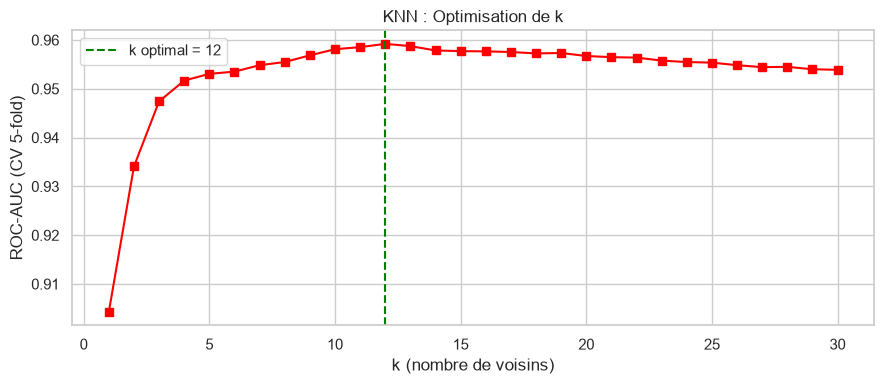

k optimal : 12 | ROC-AUC CV : 0.9592


In [7]:
k_values = range(1, 31)
cv_scores_knn = []

for k in k_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k)),
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_scores_knn.append(scores.mean())

best_k = list(k_values)[np.argmax(cv_scores_knn)]

plt.figure(figsize=(9, 4))
plt.plot(k_values, cv_scores_knn, 'rs-')
plt.axvline(best_k, color='green', linestyle='--', label=f'k optimal = {best_k}')
plt.xlabel('k (nombre de voisins)')
plt.ylabel('ROC-AUC (CV 5-fold)')
plt.title('KNN : Optimisation de k')
plt.legend()
plt.tight_layout()
plt.show()

pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=best_k)),
])
pipe_knn.fit(X_train, y_train)
print(f"k optimal : {best_k} | ROC-AUC CV : {max(cv_scores_knn):.4f}")


---
## 5. Decision Tree

Partitionne récursivement l'espace des features selon des seuils. Très interprétable mais tend à overfitter : régularisé via `max_depth`.

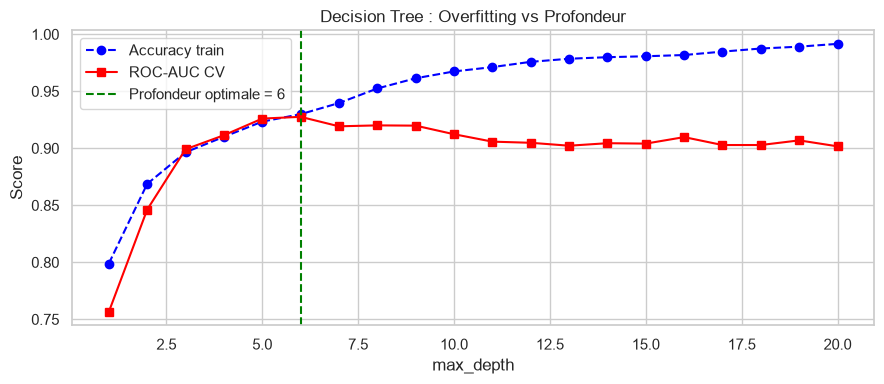

Profondeur optimale : 6 | ROC-AUC CV : 0.9276


In [8]:
depth_values = range(1, 21)
cv_scores_dt_train = []
cv_scores_dt = []

for d in depth_values:
    dt = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    dt.fit(X_train_sc, y_train)
    cv_scores_dt_train.append(accuracy_score(y_train, dt.predict(X_train_sc)))
    scores = cross_val_score(dt, X_train_sc, y_train, cv=cv, scoring='roc_auc')
    cv_scores_dt.append(scores.mean())

best_depth = list(depth_values)[np.argmax(cv_scores_dt)]

plt.figure(figsize=(9, 4))
plt.plot(depth_values, cv_scores_dt_train, 'b--o', label='Accuracy train')
plt.plot(depth_values, cv_scores_dt, 'rs-', label='ROC-AUC CV')
plt.axvline(best_depth, color='green', linestyle='--', label=f'Profondeur optimale = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('Score')
plt.title('Decision Tree : Overfitting vs Profondeur')
plt.legend()
plt.tight_layout()
plt.show()

dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
dt_best.fit(X_train_sc, y_train)
print(f"Profondeur optimale : {best_depth} | ROC-AUC CV : {max(cv_scores_dt):.4f}")


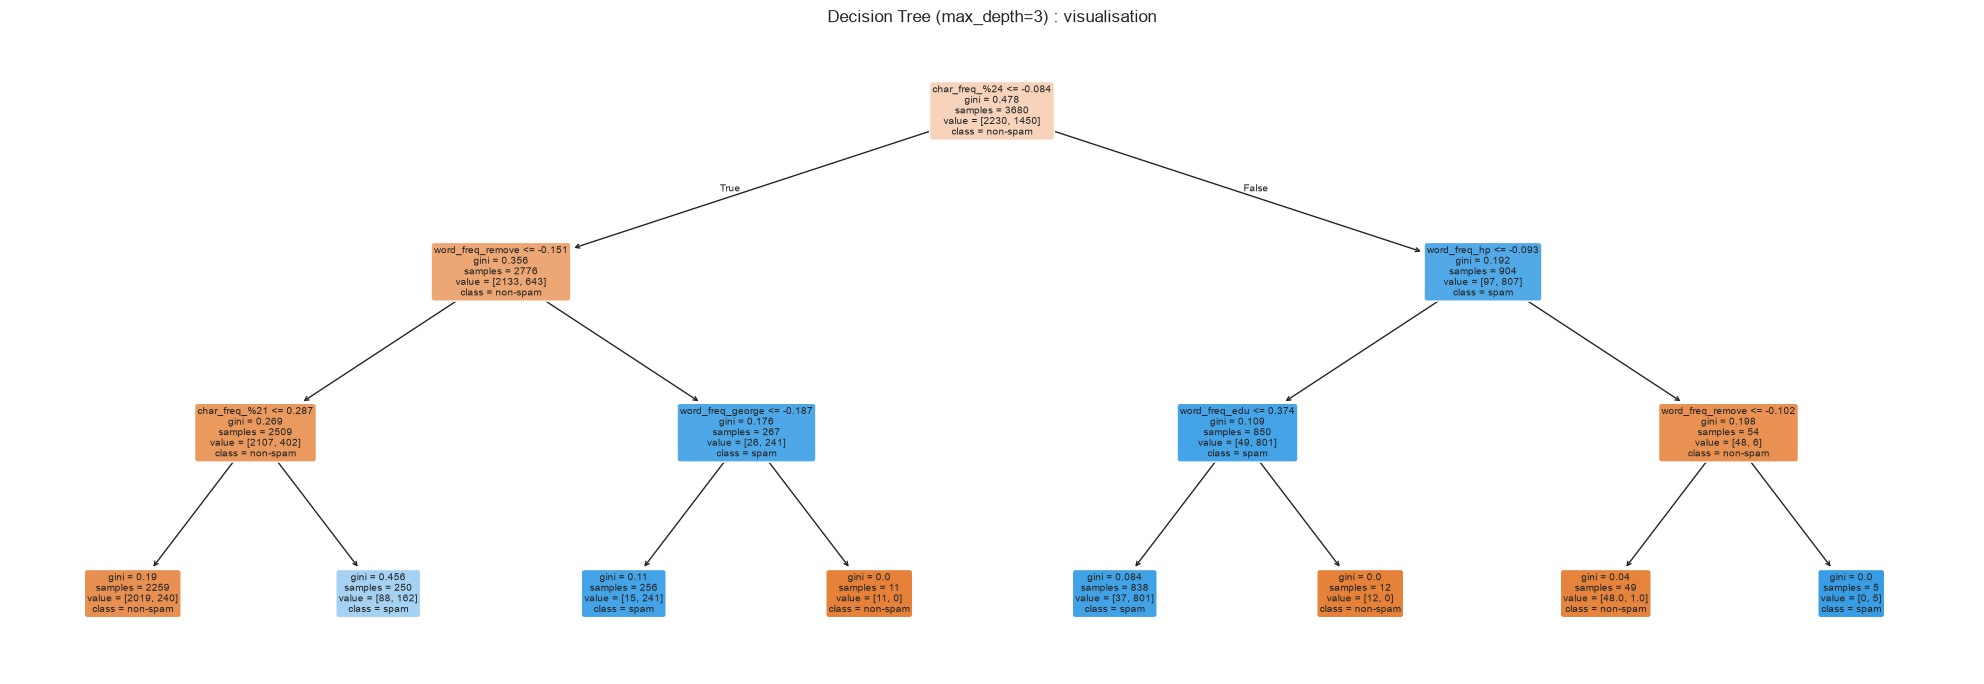

In [9]:
# Visualisation de l'arbre (profondeur 3 pour la lisibilité)
dt_viz = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
dt_viz.fit(X_train_sc, y_train)

plt.figure(figsize=(20, 7))
plot_tree(dt_viz, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=7, max_depth=3)
plt.title('Decision Tree (max_depth=3) : visualisation')
plt.tight_layout()
plt.show()


---
## 6. Random Forest

Ensemble de **N arbres de décision** entraînés sur des sous-échantillons bootstrap et des sous-ensembles de features aléatoires.

In [10]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2'],
}

rf = RandomForestClassifier(random_state=RANDOM_STATE)
gs_rf = GridSearchCV(rf, param_grid_rf, cv=cv, scoring='roc_auc', n_jobs=-1)
gs_rf.fit(X_train_sc, y_train)

print(f"Meilleurs paramètres RF : {gs_rf.best_params_}")
print(f"ROC-AUC CV             : {gs_rf.best_score_:.4f}")

rf_best = gs_rf.best_estimator_


Meilleurs paramètres RF : {'max_depth': None, 'max_features': 'log2', 'n_estimators': 200}
ROC-AUC CV             : 0.9867


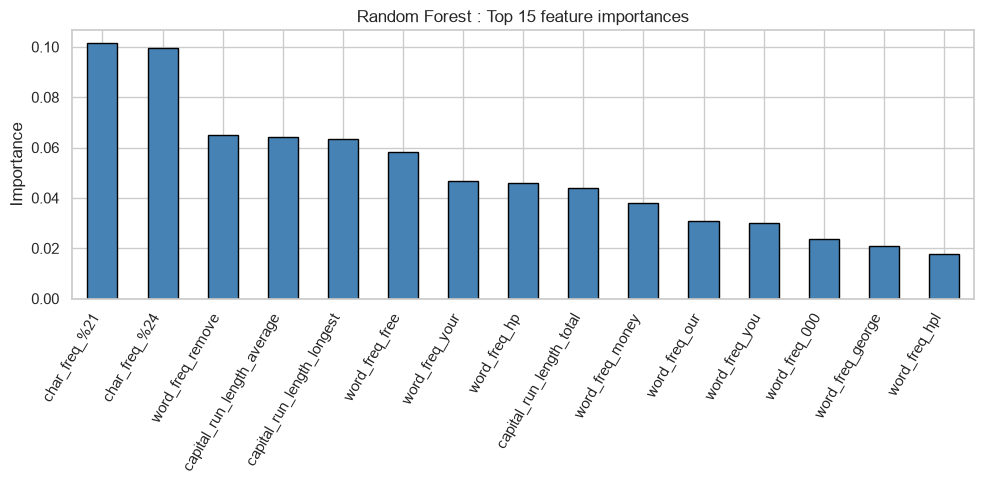

In [11]:
importances_rf = pd.Series(rf_best.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances_rf.head(15).plot(kind='bar', color='steelblue', edgecolor='k')
plt.title('Random Forest : Top 15 feature importances')
plt.ylabel('Importance')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


---
## 7. XGBoost

Boosting par gradient : construit les arbres **séquentiellement**, chaque arbre corrigeant les erreurs du précédent.

In [12]:
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
}

xgb = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)
gs_xgb = GridSearchCV(xgb, param_grid_xgb, cv=cv, scoring='roc_auc', n_jobs=-1)
gs_xgb.fit(X_train_sc, y_train)

print(f"Meilleurs paramètres XGB : {gs_xgb.best_params_}")
print(f"ROC-AUC CV              : {gs_xgb.best_score_:.4f}")

xgb_best = gs_xgb.best_estimator_


Meilleurs paramètres XGB : {'learning_rate': 0.3, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1.0}
ROC-AUC CV              : 0.9875


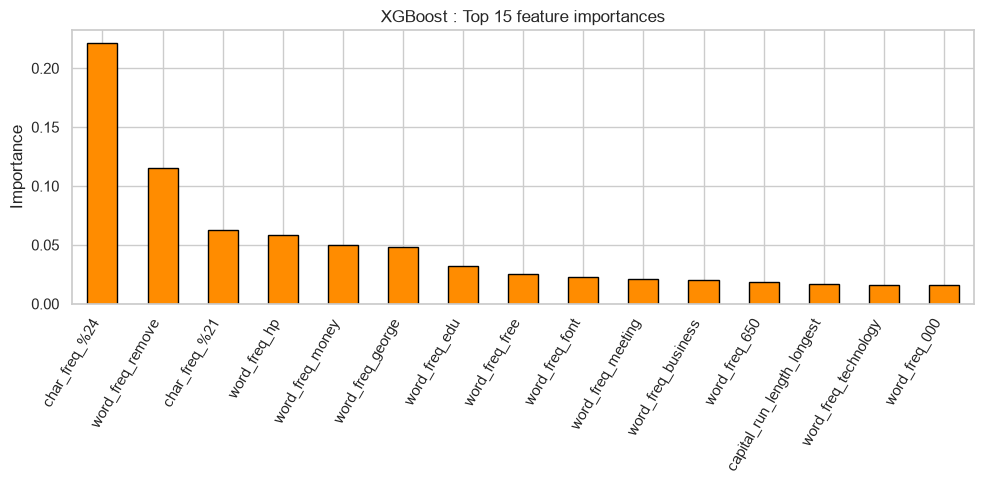

In [13]:
importances_xgb = pd.Series(xgb_best.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances_xgb.head(15).plot(kind='bar', color='darkorange', edgecolor='k')
plt.title('XGBoost : Top 15 feature importances')
plt.ylabel('Importance')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


---
## 8. Évaluation & comparaison

### 8.1 Métriques sur le jeu de test

In [14]:
models = {
    'Logistic Regression': pipe_lr,
    'KNN': pipe_knn,
    'Decision Tree': dt_best,
    'Random Forest': rf_best,
    'XGBoost': xgb_best,
}

# Les modèles DT, RF, XGBoost ont été entraînés sur X_train_sc
# LR et KNN via pipeline (scaler inclus)
results = []
for name, model in models.items():
    if name in ['Logistic Regression', 'KNN']:
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_pred = model.predict(X_test_sc)
        y_proba = model.predict_proba(X_test_sc)[:, 1]
    results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })

df_results = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
df_results.round(4)


,Modèle,Accuracy,ROC-AUC
4,XGBoost,0.9479,0.9860
3,Random Forest,0.9501,0.9837
0,Logistic Regression,0.9262,0.9688
1,KNN,0.9034,0.9627
2,Decision Tree,0.9034,0.9266


### 8.2 Courbes ROC

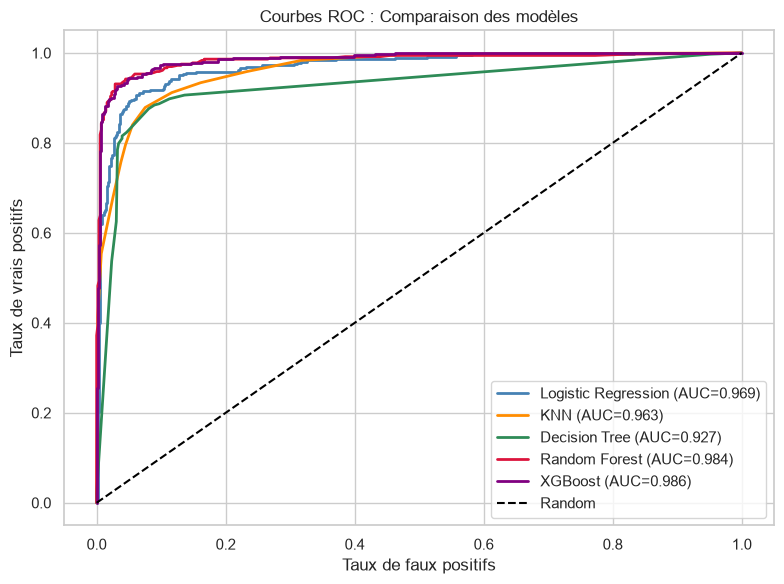

In [15]:
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'purple']

plt.figure(figsize=(8, 6))
for (name, model), color in zip(models.items(), colors):
    X_eval = X_test if name in ['Logistic Regression', 'KNN'] else X_test_sc
    y_proba = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC : Comparaison des modèles')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### 8.3 Matrices de confusion

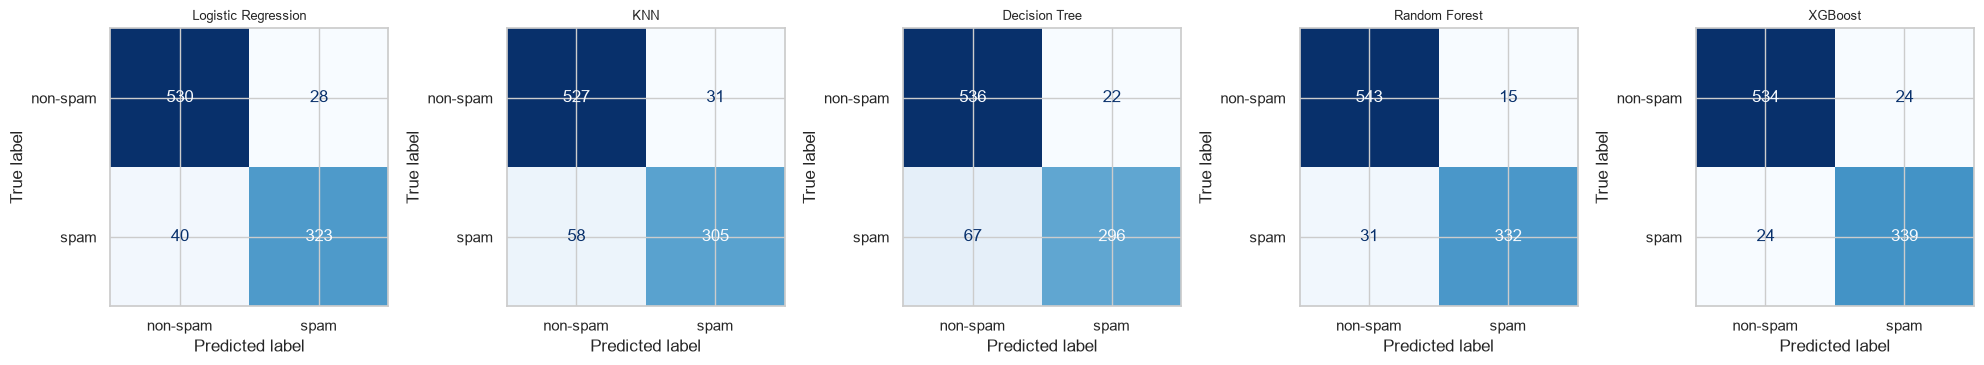

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (name, model) in zip(axes, models.items()):
    X_eval = X_test if name in ['Logistic Regression', 'KNN'] else X_test_sc
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=9)

plt.tight_layout()
plt.show()


### 8.4 Rapport de classification du meilleur modèle

In [17]:
best_model_name = df_results.iloc[0]['Modèle']
best_model = models[best_model_name]
X_eval = X_test if best_model_name in ['Logistic Regression', 'KNN'] else X_test_sc

print(f"Meilleur modèle : {best_model_name}\n")
print(classification_report(y_test, best_model.predict(X_eval), target_names=class_names))


Meilleur modèle : XGBoost

              precision    recall  f1-score   support

    non-spam       0.96      0.96      0.96       558
        spam       0.93      0.93      0.93       363

    accuracy                           0.95       921
   macro avg       0.95      0.95      0.95       921
weighted avg       0.95      0.95      0.95       921



---
## 9. Analyse de l'overfitting : courbes de validation

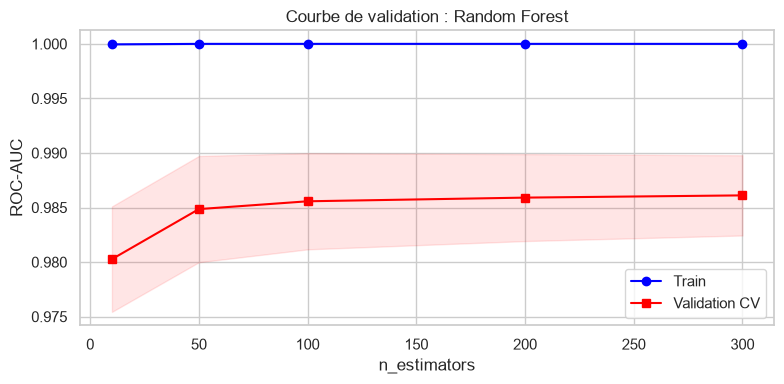

In [18]:
# Courbe de validation : RF : n_estimators
n_range = [10, 50, 100, 200, 300]
train_scores, val_scores = validation_curve(
    RandomForestClassifier(random_state=RANDOM_STATE), X_train_sc, y_train,
    param_name='n_estimators', param_range=n_range, cv=cv, scoring='roc_auc', n_jobs=-1
)

plt.figure(figsize=(8, 4))
plt.plot(n_range, train_scores.mean(axis=1), 'b-o', label='Train')
plt.fill_between(n_range, train_scores.mean(1)-train_scores.std(1), train_scores.mean(1)+train_scores.std(1), alpha=0.1, color='b')
plt.plot(n_range, val_scores.mean(axis=1), 'r-s', label='Validation CV')
plt.fill_between(n_range, val_scores.mean(1)-val_scores.std(1), val_scores.mean(1)+val_scores.std(1), alpha=0.1, color='r')
plt.xlabel('n_estimators')
plt.ylabel('ROC-AUC')
plt.title('Courbe de validation : Random Forest')
plt.legend()
plt.tight_layout()
plt.show()


---
## 10. Explicabilité avec SHAP

Un modèle boîte noire (Random Forest, XGBoost) est précis mais difficile à justifier auprès du métier. Les **valeurs de Shapley** (SHAP) attribuent à chaque variable sa contribution à une prédiction, sans changer le modèle :
$$\text{prédiction} = \text{valeur de base} + \sum_{i} \text{valeur de Shapley}(x_i)$$

On illustre la méthode sur XGBoost.

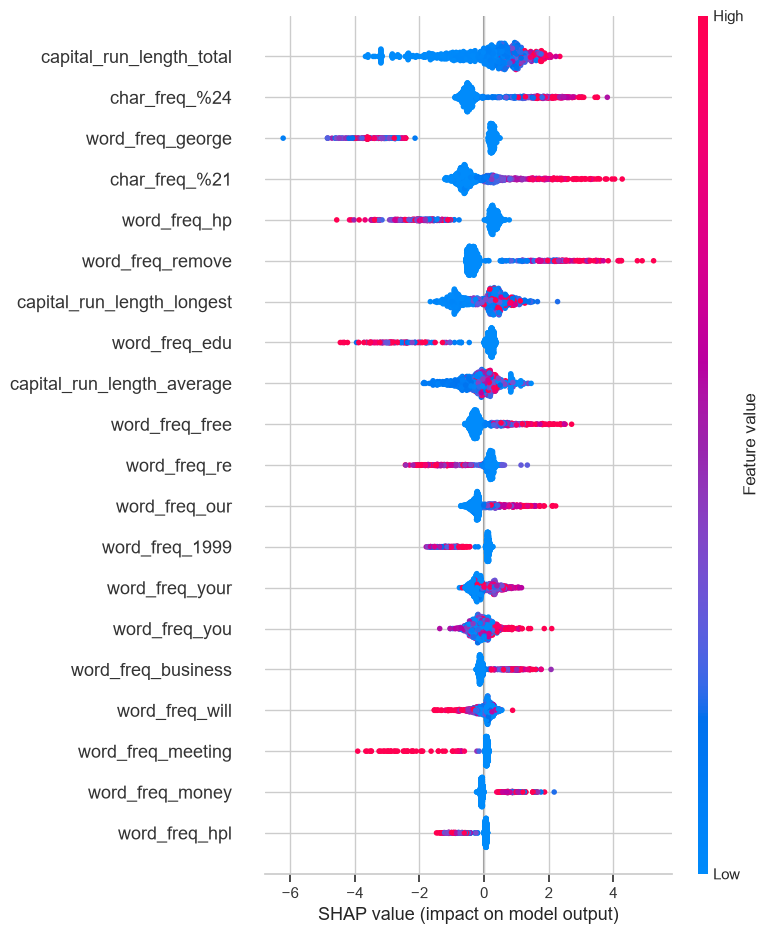

In [19]:
import shap

explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test_sc)

shap.summary_plot(shap_values, X_test_sc, feature_names=feature_names)

**Lecture du graphique (summary plot) :** chaque point est un email du jeu de test. La position horizontale indique l'impact sur la prédiction (vers la droite : pousse vers "spam", vers la gauche : pousse vers "non-spam"), et la couleur la valeur de la feature (rouge = valeur élevée, bleu = valeur faible). Les variables sont triées par impact moyen absolu (importance globale).

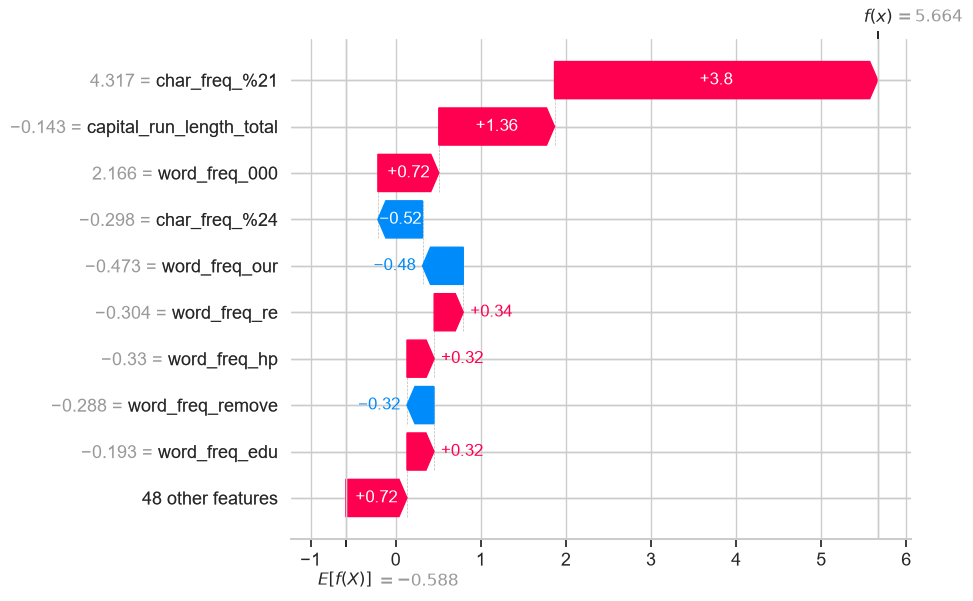

Vraie classe : spam | Prédite : spam


In [20]:
explanation = explainer(X_test_sc[:1])
explanation.feature_names = feature_names
shap.plots.waterfall(explanation[0])

print(f"Vraie classe : {class_names[y_test[0]]} | Prédite : {class_names[xgb_best.predict(X_test_sc[:1])[0]]}")

---
## 11. Choisir le modèle final : erreur, performance et explicabilité

Le modèle final ne se choisit pas seulement sur la métrique de performance : trois critères entrent en jeu :
1. **Minimiser l'erreur** (ici : 1 - accuracy)
2. **Maximiser la performance** (ici : ROC-AUC, robuste au déséquilibre de classes)
3. **Maximiser l'explicabilité** (nativement interprétable, ou via SHAP pour une boîte noire)

In [21]:
explicabilite = {
    'Logistic Regression': 'Haute (coefficients directs)',
    'KNN': 'Faible (pas de règle ni de coefficient)',
    'Decision Tree': 'Très haute (règles lisibles)',
    'Random Forest': 'Moyenne (boîte noire, expliquée via SHAP)',
    'XGBoost': 'Moyenne (boîte noire, expliquée via SHAP)',
}

df_choix = df_results.copy()
df_choix['Erreur (1 - Accuracy)'] = 1 - df_choix['Accuracy']
df_choix['Explicabilité'] = df_choix['Modèle'].map(explicabilite)
df_choix = df_choix[['Modèle', 'Erreur (1 - Accuracy)', 'ROC-AUC', 'Explicabilité']]
df_choix.round(4)

,Modèle,Erreur (1 - Accuracy),ROC-AUC,Explicabilité
4,XGBoost,0.0521,0.9860,"Moyenne (boîte noire, expliquée via SHAP)"
3,Random Forest,0.0499,0.9837,"Moyenne (boîte noire, expliquée via SHAP)"
0,Logistic Regression,0.0738,0.9688,Haute (coefficients directs)
1,KNN,0.0966,0.9627,Faible (pas de règle ni de coefficient)
2,Decision Tree,0.0966,0.9266,Très haute (règles lisibles)


In [22]:
best_final_name = df_results.iloc[0]['Modèle']
best_final_model = models[best_final_name]

print(f"Modèle final retenu : {best_final_name}")
print(f"  Erreur (1 - Accuracy) : {1 - df_results.iloc[0]['Accuracy']:.4f}")
print(f"  ROC-AUC               : {df_results.iloc[0]['ROC-AUC']:.4f}")
print(f"  Explicabilité         : {explicabilite[best_final_name]}")

Modèle final retenu : XGBoost
  Erreur (1 - Accuracy) : 0.0521
  ROC-AUC               : 0.9860
  Explicabilité         : Moyenne (boîte noire, expliquée via SHAP)


---
## 12. Stocker le modèle final

In [23]:
import joblib
import os

os.makedirs('modeles', exist_ok=True)
joblib.dump(best_final_model, 'modeles/best_model_classification.pkl')

# best_final_model n'est pas un Pipeline : il a été entraîné sur X_train_sc,
# le scaler doit donc être sauvegardé séparément pour l'inférence.
if not isinstance(best_final_model, Pipeline):
    joblib.dump(scaler, 'modeles/scaler_classification.pkl')

print(f"Modèle sauvegardé : modeles/best_model_classification.pkl ({best_final_name})")

Modèle sauvegardé : modeles/best_model_classification.pkl (XGBoost)


Si `best_final_model` est un `Pipeline` scikit-learn (normalisation + modèle, comme pour Logistic Regression ou KNN dans ce TP), un seul fichier suffit. Si le modèle retenu a été entraîné sur des données déjà standardisées à la main (comme Decision Tree, Random Forest ou XGBoost ici, via `X_train_sc`), il faut aussi sauvegarder le `scaler` séparément (`joblib.dump(scaler, ...)`).

---
## 13. Inférence simple, sans API

In [24]:
# Nouvelles données à prédire (ici, un échantillon du jeu de test, pour l'exemple :
# en production ces lignes viendraient d'une nouvelle source, pas du jeu de test)
nouvelles_donnees = pd.DataFrame(X_test[:10], columns=feature_names)

model_charge = joblib.load('modeles/best_model_classification.pkl')

if isinstance(model_charge, Pipeline):
    X_infer = nouvelles_donnees
else:
    X_infer = joblib.load('modeles/scaler_classification.pkl').transform(nouvelles_donnees)

predictions = model_charge.predict(X_infer)
probabilites = model_charge.predict_proba(X_infer)[:, 1]

nouvelles_donnees['prediction'] = [class_names[p] for p in predictions]
nouvelles_donnees['probabilite_spam'] = probabilites.round(4)
nouvelles_donnees.to_csv('predictions_classification.csv', index=False)

print(f"Prédictions sauvegardées : predictions_classification.csv ({len(nouvelles_donnees)} lignes)")
nouvelles_donnees[['prediction', 'probabilite_spam']]

Prédictions sauvegardées : predictions_classification.csv (10 lignes)


,prediction,probabilite_spam
0,spam,0.9965
1,spam,0.9998
2,non-spam,0.0042
3,spam,0.9557
4,non-spam,0.0004
5,non-spam,0.0004
6,non-spam,0.0014
7,spam,0.9566
8,non-spam,0.0004
9,spam,0.9853


---
## 14. Conclusion

| Critère | LogReg | KNN | Decision Tree | Random Forest | XGBoost |
|---|---|---|---|---|---|
| Interprétabilité | ★★★★ | ★★ | ★★★★★ | ★★ | ★★ |
| Performance typique | ★★★ | ★★★ | ★★★ | ★★★★ | ★★★★★ |
| Sensible à l'échelle | Oui | Oui | Non | Non | Non |
| Risque d'overfitting | Faible | Moyen | Élevé | Faible | Moyen (à régler) |

**À retenir :** sur un problème de détection de spam, le rappel (ne pas rater de spam) et la précision (ne pas bloquer un email légitime) ont un coût très différent : le choix du modèle final dépend du seuil de décision et du contexte métier.

---
## Session à rendre

Cette section est à compléter et à rendre à l'issue du TP. Réponds à chaque question dans la
cellule *Réponse* juste en dessous, à partir des résultats que **tu as toi-même obtenus** en
réalisant ce notebook (il n'y a pas de réponse générique valable pour tout le monde : les valeurs
numériques, choix d'hyperparamètres et graphiques dépendent de ton exécution).

**Q1.** Quel C as-tu retenu pour la régression logistique, et comment as-tu arbitré entre les valeurs testées ?

*Réponse :*

J'ai retenu **C = 10**, qui donne le meilleur ROC-AUC en cross-validation 5-fold : **0.9709**.

Arbitrage : les valeurs testées vont de 0.001 à 100. En dessous de C = 0.1 la régularisation est trop forte (le modèle sous-apprend, l'AUC chute nettement). À partir de C = 1, la courbe s'aplatit : C = 10 arrive en tête, mais l'écart avec C = 1 et C = 100 se joue à quelques millièmes d'AUC, ce qui est de l'ordre du bruit de la CV. Le choix de C = 10 est donc celui du maximum mesuré, sans différence pratique réelle avec ses voisins — si je devais privilégier la simplicité et la stabilité, C = 1 (régularisation plus forte) serait un choix tout aussi défendable.

**Q2.** Quel k as-tu choisi pour KNN, sur quel critère ?

*Réponse :*

J'ai choisi **k = 12**, sur le critère du **ROC-AUC moyen en cross-validation 5-fold** (le même que pour les autres modèles, pour que la comparaison finale soit cohérente) : **0.9592**.

Critère et lecture de la courbe : k = 1 donne le score le plus faible, car le modèle colle au bruit (chaque point est classé par son unique voisin, donc aucune moyenne pour lisser les erreurs). L'AUC monte quand k augmente, atteint son maximum vers k = 12, puis se dégrade lentement pour les grands k : le voisinage devient trop large et lisse les frontières entre spam et non-spam. La normalisation est indispensable ici, car les `capital_run_length_*` (des longueurs, jusqu'à plusieurs centaines) écraseraient sinon complètement les `word_freq_*` (des pourcentages entre 0 et ~10) dans le calcul de la distance euclidienne — c'est pourquoi le KNN est encapsulé dans un `Pipeline` avec le `StandardScaler`.

**Q3.** Quelle profondeur maximale as-tu retenue pour l'arbre de décision ? As-tu observé du surapprentissage (écart train/test) pour les profondeurs plus grandes ?

*Réponse :*

J'ai retenu **max_depth = 6** (ROC-AUC CV = **0.9276**).

**Oui, le surapprentissage est très net au-delà de 6.** Les deux courbes se séparent franchement — l'accuracy sur le train continue de monter pendant que l'AUC en validation croisée redescend :

| max_depth | Accuracy train | ROC-AUC CV |
|---|---|---|
| 4 | 0.9101 | 0.9114 |
| **6** | **0.9299** | **0.9276** ← maximum |
| 8 | 0.9524 | 0.9201 |
| 12 | 0.9758 | 0.9048 |
| 20 | 0.9916 | 0.9017 |

À `max_depth = 20`, l'arbre classe presque parfaitement ses données d'entraînement (99.2 %) alors que sa performance en validation est *inférieure* à celle d'un arbre trois fois moins profond : les feuilles ne contiennent plus que quelques emails et encodent des particularités du jeu d'entraînement plutôt que des règles généralisables. C'est l'illustration typique du compromis biais-variance : avant 6, l'arbre sous-apprend (les deux courbes montent ensemble) ; après 6, il mémorise.

**Q4.** Quels hyperparamètres GridSearchCV a-t-il sélectionnés pour le Random Forest et pour XGBoost ?

*Réponse :*

**Random Forest** (18 combinaisons × 5 folds = 90 entraînements) :

| Hyperparamètre | Valeur retenue |
|---|---|
| `n_estimators` | 200 |
| `max_depth` | `None` (arbres développés au maximum) |
| `max_features` | `log2` |

→ ROC-AUC CV = **0.9867**

**XGBoost** (36 combinaisons × 5 folds = 180 entraînements) :

| Hyperparamètre | Valeur retenue |
|---|---|
| `n_estimators` | 100 |
| `max_depth` | 7 |
| `learning_rate` | 0.3 |
| `subsample` | 1.0 |

→ ROC-AUC CV = **0.9875**

Deux remarques sur ces choix. D'abord, la forêt retient `max_depth=None` alors que l'arbre seul plafonnait à 6 : ce n'est pas contradictoire, c'est le principe même du bagging. Des arbres profonds pris isolément surapprennent (variance élevée), mais en moyenner 200, entraînés chacun sur un échantillon bootstrap et un sous-ensemble de features, annule cette variance — la forêt n'a donc pas besoin d'être régularisée par la profondeur. Ensuite, XGBoost compense un `learning_rate` élevé (0.3) par peu d'arbres (100) : les deux paramètres jouent l'un contre l'autre, un pas d'apprentissage fort permettant de converger en moins d'itérations.

**Q5.** D'après ton tableau récapitulatif, quel modèle obtient les meilleures performances, et selon quelle métrique ? Pour un filtre anti-spam, pourquoi privilégier la précision ou le rappel selon le cas (coût d'un faux positif : un email légitime classé comme spam) ?

*Réponse :*

Résultats sur le jeu de test (921 emails), triés par ROC-AUC :

| Modèle | Accuracy | ROC-AUC |
|---|---|---|
| **XGBoost** | 0.9479 | **0.9860** |
| Random Forest | **0.9501** | 0.9837 |
| Logistic Regression | 0.9262 | 0.9688 |
| KNN | 0.9034 | 0.9627 |
| Decision Tree | 0.9034 | 0.9266 |

**La réponse dépend de la métrique**, et c'est le point intéressant : **XGBoost** est premier en **ROC-AUC** (0.9860), mais c'est **Random Forest** qui a la meilleure **accuracy** (0.9501 contre 0.9479). Les deux modèles sont donc à égalité pratique — l'écart (0.002 d'AUC, soit ~2 emails sur 921) est inférieur à la variabilité qu'on obtiendrait en changeant le `random_state`. Je retiens le classement par ROC-AUC parce que cette métrique évalue la qualité du *classement* des probabilités indépendamment du seuil, alors que l'accuracy fige le seuil à 0.5 — or c'est précisément ce seuil qu'on veut pouvoir régler dans un filtre anti-spam. Les deux ensembles devancent nettement les modèles simples, et l'arbre seul ferme la marche.

**Précision ou rappel pour un filtre anti-spam ?** Les deux erreurs n'ont pas du tout le même coût :

- Un **faux positif** = un email légitime classé spam → il part dans le dossier spam et l'utilisateur ne le voit jamais. Si c'est une convocation d'entretien ou une facture, le préjudice est réel et irrattrapable.
- Un **faux négatif** = un spam qui arrive en boîte de réception → l'utilisateur le voit, le supprime en deux secondes. Agaçant, sans plus.

Le coût est donc très asymétrique, et **c'est la précision sur la classe "spam" qu'il faut privilégier** : mieux vaut laisser passer quelques spams que perdre un seul email important. Concrètement, cela veut dire **relever le seuil de décision** au-dessus de 0.5 (ne classer en spam qu'à partir de ~0.9 de probabilité), ce qui augmente la précision au prix du rappel. Mon modèle final est à 0.93 de précision et 0.93 de rappel sur "spam" au seuil par défaut : environ 25 emails légitimes sur 558 finissent en spam, ce qui serait inacceptable en production et justifierait pleinement ce réglage de seuil.

Le raisonnement s'inverserait dans un contexte où le faux négatif coûte cher — détection de fraude ou dépistage médical, où rater un cas positif est le vrai danger : là, c'est le rappel qu'on maximise.

**Q6.** Que montre la courbe de validation_curve que tu as tracée : à partir de quel réglage le modèle commence-t-il à surapprendre ?

*Réponse :*

| n_estimators | Train | Validation CV |
|---|---|---|
| 10 | 1.0000 | 0.9803 |
| 50 | 1.0000 | 0.9849 |
| 100 | 1.0000 | 0.9856 |
| 200 | 1.0000 | 0.9859 |
| 300 | 1.0000 | 0.9861 |

**Réponse directe : à aucun réglage — cette courbe ne montre pas d'entrée en surapprentissage, et c'est justement ce qu'elle enseigne.** Contrairement à la courbe de l'arbre de décision (Q3), où la validation redescendait clairement après `max_depth = 6`, ici la courbe de validation ne redescend jamais : elle monte de 0.9803 à 0.9861 puis se stabilise. **Ajouter des arbres à une forêt aléatoire ne fait pas surapprendre.**

La raison : chaque arbre est entraîné indépendamment sur un échantillon bootstrap différent, et la prédiction finale est leur moyenne. Augmenter `n_estimators` ne fait que moyenner sur davantage d'arbres, ce qui **réduit la variance** de l'ensemble sans jamais augmenter son biais. C'est un paramètre qui ne peut que converger, contrairement à `max_depth` qui contrôle réellement la capacité du modèle.

**Attention au piège de lecture** : l'AUC train vaut 1.0000 partout, et l'écart train/validation (~0.014) pourrait faire croire à du surapprentissage. Mais cet écart est **constant dès n = 10** — il ne se creuse pas. Il vient de `max_depth=None` : chaque arbre, développé jusqu'à des feuilles pures, mémorise parfaitement ses données d'entraînement. Le surapprentissage individuel des arbres est réel, mais il est déjà compensé par le bagging, et il n'a rien à voir avec `n_estimators`.

**Conclusion pratique :** le vrai enseignement de cette courbe est un point de **rendements décroissants**, pas de surapprentissage. Au-delà de **n = 100**, on gagne 0.0005 d'AUC en triplant le nombre d'arbres — donc en triplant le temps de calcul et la taille du modèle. Le GridSearch a retenu 200 (le maximum de sa grille), mais **100 arbres suffisent largement** : c'est le bon compromis performance/coût. Pour voir du surapprentissage sur cette forêt, il aurait fallu tracer la courbe sur `max_depth` ou `min_samples_leaf`.

**Q7.** Sur le summary plot SHAP de XGBoost, quelles sont les 2-3 variables qui ont le plus d'impact sur la détection de spam ?

*Réponse :*

Top des variables par impact moyen absolu (moyenne des |valeurs de Shapley| sur les 921 emails du test) :

| Rang | Variable | Impact moyen \|SHAP\| | Signification |
|---|---|---|---|
| 1 | `capital_run_length_total` | 0.94 | Nombre total de lettres majuscules |
| 2 | `char_freq_%24` | 0.80 | Fréquence du caractère **`$`** |
| 3 | `word_freq_george` | 0.80 | Fréquence du mot "george" |
| 4 | `char_freq_%21` | 0.73 | Fréquence du caractère **`!`** |
| 5 | `word_freq_hp` | 0.72 | Fréquence du mot "hp" |
| 6 | `word_freq_remove` | 0.69 | Fréquence du mot "remove" |

**Les 3 variables les plus impactantes sont `capital_run_length_total`, `char_freq_$` et `word_freq_george`.**

Les deux premières sont **parfaitement interprétables et généralisables** : sur le summary plot, leurs valeurs élevées (points rouges) sont à droite, donc poussent vers "spam". C'est exactement l'intuition qu'on a du spam — l'abus de MAJUSCULES ("ACHETEZ MAINTENANT") et les symboles monétaires. Idem pour `!` et "remove" (typique des liens de désinscription frauduleux).

**En revanche, `word_freq_george` et `word_freq_hp` sont un signal d'alarme, pas un succès.** Ces mots n'ont rien d'universellement anti-spam : le dataset Spambase a été construit à partir de la boîte mail d'un employé de **Hewlett-Packard** nommé **George**. Le modèle a donc appris que « si l'email mentionne george ou hp, c'est du courrier professionnel légitime » — sur le summary plot, ces variables poussent vers "non-spam" quand elles sont élevées. C'est une **fuite de contexte** (le modèle exploite l'identité du destinataire, pas la nature du message) : ces règles n'ont aucune valeur pour un autre utilisateur et le modèle s'effondrerait déployé sur une autre boîte mail. C'est précisément ce genre de biais que SHAP permet de détecter — la métrique seule (0.986 d'AUC) était excellente et ne le montrait pas.

Sur le **waterfall plot** de la première observation du test (vraie classe : spam, prédite : spam), on voit la décomposition individuelle : partant de la valeur de base, chaque variable ajoute ou retranche sa contribution jusqu'à la prédiction finale — ce qui permet de justifier une décision email par email auprès d'un utilisateur qui conteste un blocage.

**Q8.** Quel modèle final as-tu obtenu après arbitrage erreur/performance/explicabilité (section 11) ? Est-ce le même que le "meilleur" modèle de la section 8 ? Pourquoi ?

*Réponse :*

**Modèle final : XGBoost** — erreur 0.0521, ROC-AUC 0.9860, explicabilité moyenne (boîte noire, rattrapée par SHAP).

**Oui, c'est le même modèle qu'en section 8**, et c'est une conséquence directe du code : `best_final_name = df_results.iloc[0]['Modèle']` reprend la première ligne d'un `df_results` déjà trié par ROC-AUC. L'arbitrage de la section 11 est donc, tel qu'il est codé, un choix **par la seule performance** — les colonnes "Erreur" et "Explicabilité" sont affichées pour la réflexion mais n'entrent pas dans la décision automatique.

**Ce tri automatique mérite d'être discuté, car les trois critères ne désignent pas le même gagnant :**

| Critère | Gagnant |
|---|---|
| ROC-AUC (performance) | XGBoost (0.9860) |
| Erreur = 1 - accuracy | **Random Forest** (0.0499 contre 0.0521) |
| Explicabilité | **Decision Tree** (règles lisibles) |

XGBoost ne gagne donc que sur un critère sur trois. Il est même **battu par Random Forest sur le critère n°1 de la section 11** (minimiser l'erreur) : la forêt fait 46 erreurs sur 921 contre 48 pour XGBoost. Prendre `iloc[0]` de `df_results` revient à trancher en faveur du ROC-AUC sans le dire, alors que l'écart entre les deux ensembles (0.002 d'AUC, ~2 emails) n'est pas significatif.

**Mon choix raisonné** : je garde XGBoost, mais pas parce qu'il est en tête du tableau. Comme XGBoost et Random Forest sont statistiquement à égalité et tous deux des boîtes noires de même explicabilité, le départage se fait sur le ROC-AUC, qui est la métrique pertinente ici — un filtre anti-spam doit pouvoir régler son seuil de décision (cf. Q5), et l'AUC est la seule des deux métriques qui mesure la qualité du modèle indépendamment de ce seuil. L'accuracy, elle, fige le seuil à 0.5, un réglage qu'on ne garderait de toute façon pas en production.

Le vrai perdant de cet arbitrage est le **Decision Tree** : imbattable en explicabilité, mais son AUC (0.9266) est trop en retrait pour être défendable. Dans un contexte où la justification légale primerait (scoring bancaire, décision médicale), l'arbitrage pourrait basculer en sa faveur — ici, SHAP permet d'expliquer XGBoost *a posteriori*, ce qui supprime l'avantage décisif de l'arbre.

**Q9.** Sur les 10 nouvelles prédictions sauvegardées dans `predictions_classification.csv`, combien sont classées comme spam ?

*Réponse :*

**5 sur 10** sont classées comme spam (lignes 0, 1, 3, 7, 9) — les 5 autres en non-spam.

| Ligne | Prédiction | Probabilité de spam |
|---|---|---|
| 0 | spam | 0.9965 |
| 1 | spam | 0.9998 |
| 2 | non-spam | 0.0042 |
| 3 | spam | 0.9557 |
| 4 | non-spam | 0.0004 |
| 5 | non-spam | 0.0004 |
| 6 | non-spam | 0.0014 |
| 7 | spam | 0.9566 |
| 8 | non-spam | 0.0004 |
| 9 | spam | 0.9853 |

Ce qui frappe, c'est que **le modèle est très sûr de lui sur les 10 cas** : toutes les probabilités sont soit au-dessus de 0.95, soit en dessous de 0.005 — aucune ne s'approche de la zone d'incertitude autour de 0.5. Conséquence pratique intéressante : relever le seuil de décision à 0.9 pour privilégier la précision (cf. Q5) ne changerait **aucune** de ces 10 prédictions. Le réglage du seuil ne joue que sur la minorité d'emails ambigus.

Deux réserves de méthode, en revanche. D'abord, ces 10 lignes viennent du **jeu de test** (`X_test[:10]`) : c'est un exemple pédagogique d'inférence, mais ce ne sont pas de vraies nouvelles données — en production elles proviendraient d'une source externe. Ensuite, la proportion 5/10 n'a **aucune valeur statistique** : c'est un échantillon de 10 lignes, alors que le jeu de test complet contient 39 % de spam (363 sur 921).

Côté technique, l'inférence recharge bien les deux artefacts sauvegardés : le modèle (`best_model_classification.pkl`) **et** le `scaler` (`scaler_classification.pkl`). C'est indispensable ici, car XGBoost a été entraîné sur `X_train_sc` et n'est pas un `Pipeline` : sans réappliquer exactement la même standardisation qu'à l'entraînement, les prédictions seraient fausses.